# [LAB 09] 2. 명목형 변수에 대한 기초 통계량

In [1]:
from hossam import load_data
from pandas import crosstab
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb

In [2]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [3]:
origin = load_data("score")
origin

[data] https://data.hossam.kr/data/lab09/score.xlsx
[desc] 명목형 변수에 대한 탐색적 데이터 분석을 위한 샘플 데이터
[!] Cannot read metadata


,gender,score
0,M,A
1,M,C
2,M,B
3,M,B
4,W,A
5,W,C
6,W,C
7,W,B


In [4]:
df = origin.astype({'gender':'category','score':'category'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   gender  8 non-null      category
 1   score   8 non-null      category
dtypes: category(2)
memory usage: 404.0 bytes


In [6]:
df.describe(include='category')

,gender,score
count,8,8
unique,2,3
top,M,B
freq,4,3


In [9]:
for i in df.columns:
    print("===", i, "===")
    print(df[i].value_counts())

=== gender ===
gender
M    4
W    4
Name: count, dtype: int64
=== score ===
score
B    3
C    3
A    2
Name: count, dtype: int64


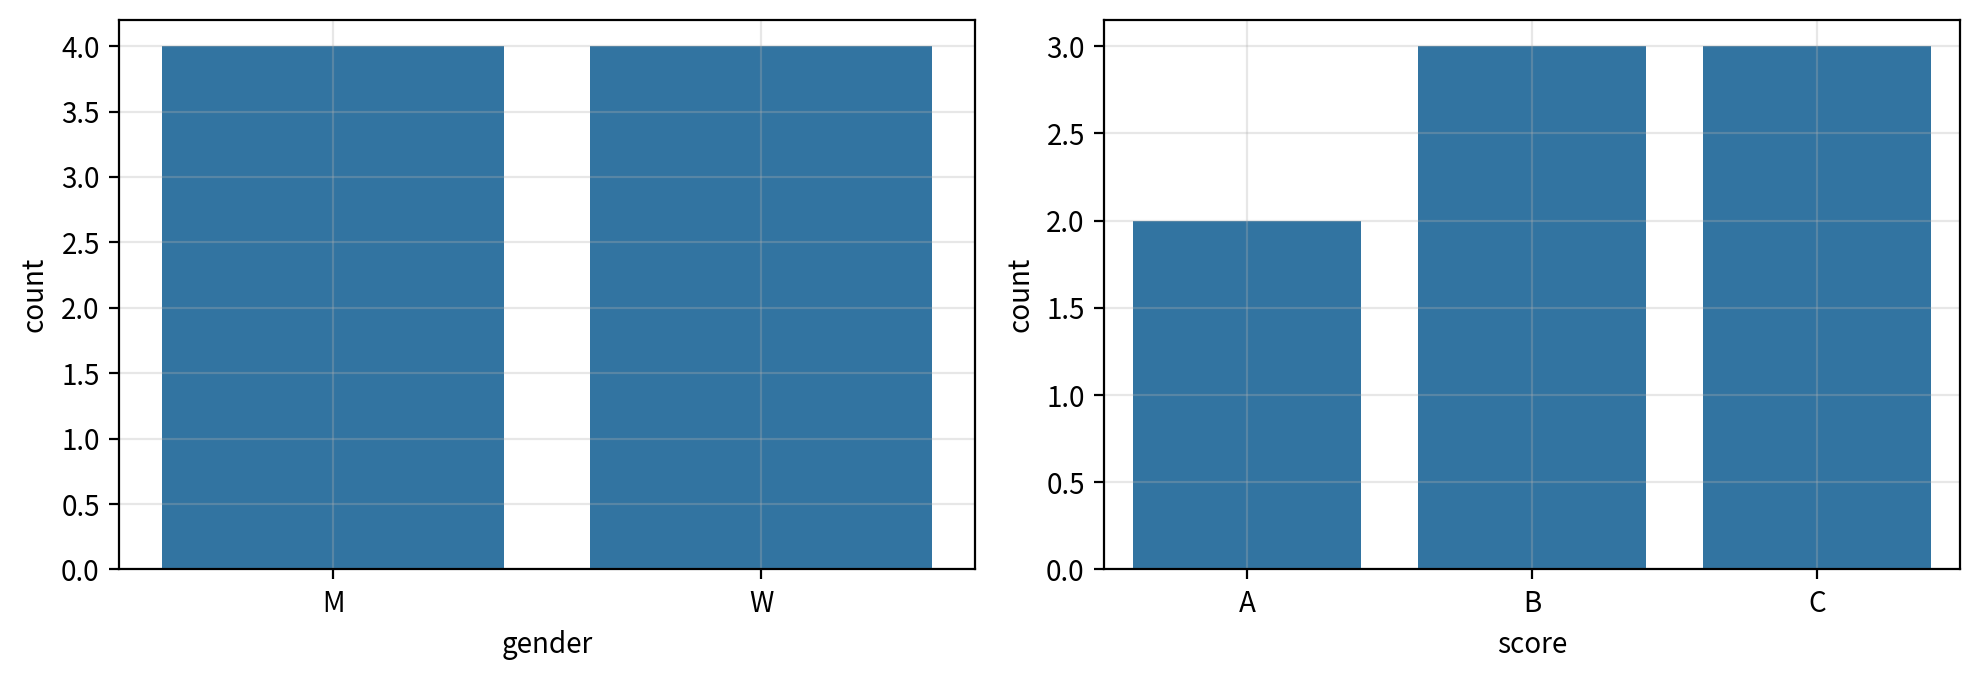

In [10]:
# 1) 그래프 초기화
width_px = 2000 # 그래프 가로 크기
height_px = 700 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 2 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
# ax 객체가 행,열 수에 따라서 리스트가 된다.
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) 그래프 그리기
for i, v in enumerate(df.columns):
    sb.countplot(data=df, x=v, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

In [13]:
cb1 = crosstab(index=df['gender'], columns=df['score'],
               rownames=['성별'], colnames=['점수'])
cb1

점수,A,B,C
성별,,,
M,1,2,1
W,1,1,2


In [14]:
cb2 = crosstab(index=origin['gender'], columns=origin['score'],
 rownames=['성별'], colnames=['점수'], margins=True,
 normalize=True)
cb2

점수,A,B,C,All
성별,,,,
M,0.125,0.250,0.125,0.5
W,0.125,0.125,0.250,0.5
All,0.250,0.375,0.375,1.0


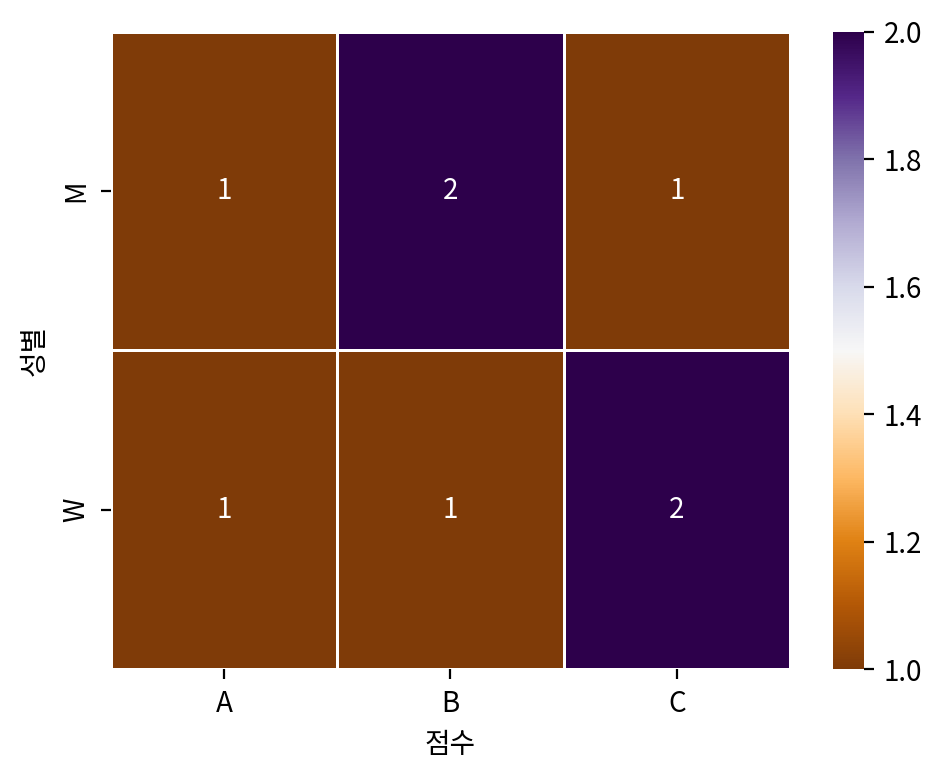

In [15]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

#2) 그래프 그리기 -> seaborn 사용
sb.heatmap(data=cb1, annot=True, fmt="d", linewidth=0.5,cmap="PuOr")


# 4) 출력

plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()